<a href="https://colab.research.google.com/github/amancommits/flight-price-prediction/blob/main/flight_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load competition data
# Dataset files are not included in this repository.
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
train.shape


(40000, 12)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10000 non-null  int64  
 1   airline      9452 non-null   object 
 2   flight       10000 non-null  object 
 3   source       10000 non-null  object 
 4   departure    9080 non-null   object 
 5   stops        9349 non-null   object 
 6   arrival      10000 non-null  object 
 7   destination  10000 non-null  object 
 8   class        10000 non-null  object 
 9   duration     9418 non-null   float64
 10  days_left    9304 non-null   float64
dtypes: float64(2), int64(1), object(8)
memory usage: 859.5+ KB


In [ ]:
train.sample(10)

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
325,325,Vistara,UK-832,Chennai,Early_Morning,one,Night,Mumbai,Economy,14.33,30.0,5772
26979,26979,Vistara,UK-824,Chennai,Night,one,Evening,Bangalore,Economy,22.75,23.0,4656
82,82,Air_India,AI-663,Mumbai,NaN,one,Night,Bangalore,Economy,9.08,30.0,5460
38349,38349,Indigo,0.00E+00,Hyderabad,Afternoon,one,Night,Kolkata,Economy,6.17,12.0,6207
7241,7241,NaN,UK-874,Hyderabad,Morning,one,Afternoon,Delhi,Business,5.58,28.0,51875
15532,15532,Vistara,UK-708,Kolkata,Night,one,Morning,Bangalore,Business,14.42,31.0,60978
17241,17241,GO_FIRST,G8-512,Kolkata,Early_Morning,one,Evening,Bangalore,Economy,14.75,14.0,6488
3477,3477,NaN,UK-834,Chennai,Evening,one,Morning,Bangalore,Business,18.67,17.0,60260
32623,32623,Vistara,UK-817,Delhi,Evening,one,Night,Mumbai,Economy,NaN,28.0,6296
33401,33401,Vistara,UK-822,Chennai,Morning,one,Afternoon,Delhi,Economy,4.75,29.0,5206


In [ ]:
train['departure'].nunique()

6

(array([2.5461e+04, 2.3590e+03, 9.0300e+02, 2.4520e+03, 4.8090e+03,
        3.1290e+03, 6.2800e+02, 2.2100e+02, 3.2000e+01, 6.0000e+00]),
 array([  1105. ,  12464.9,  23824.8,  35184.7,  46544.6,  57904.5,
         69264.4,  80624.3,  91984.2, 103344.1, 114704. ]),
 <BarContainer object of 10 artists>)

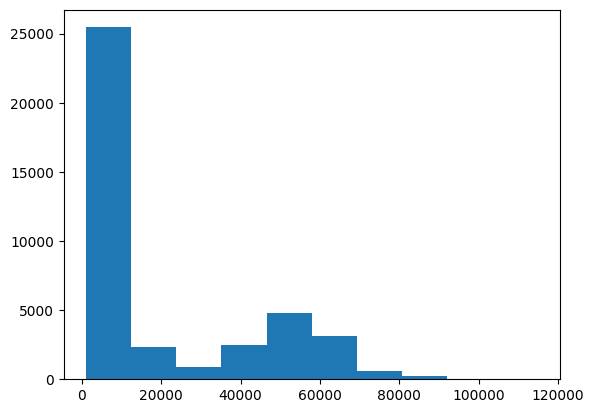

In [ ]:
plt.hist(train['price'])

In [ ]:
train.groupby('airline')['price'].agg(['mean', 'median', 'count']).sort_values('count', ascending=False)

,mean,median,count
airline,,,
Vistara,30467.990573,15794.0,15063
Air_India,23846.227391,11627.0,9222
Indigo,5200.284568,4417.0,5236
GO_FIRST,5570.071658,5292.0,2805
AirAsia,4088.886619,3201.0,1958
SpiceJet,5990.723481,5509.0,1103


In [ ]:
train.groupby('stops')['price'].agg(['mean', 'median', 'count']).sort_values('count', ascending=False)

,mean,median,count
stops,,,
one,22889.962372,7950.0,31439
zero,9379.532377,4454.0,4741
two_or_more,13235.023984,8111.0,1501


In [ ]:
train.groupby('departure')['price'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False)

,mean,median,count
departure,,,
Morning,21728.839316,8092.0,8302
Night,22982.651670,7767.0,5690
Evening,21144.228175,7352.0,7709
Early_Morning,20294.241782,6968.0,7788
Afternoon,17790.170710,6489.0,5565
Late_Night,8055.551948,4409.5,154


In [ ]:
train.groupby('class')['price'].agg(['mean', 'median', 'count']).sort_values('count', ascending=False)

,mean,median,count
class,,,
Economy,6453.775276,5660.0,27536
Business,52499.073652,53209.0,12464


In [ ]:
train.groupby('duration')['price'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False)

,mean,median,count
duration,,,
32.00,45980.800000,67710.0,5
34.33,62354.000000,61234.0,4
30.25,43348.363636,59254.0,11
18.42,38361.125000,55598.5,16
21.58,34639.644444,50969.0,45
...,...,...,...
1.08,2647.157895,1776.0,76
1.17,2592.227642,1715.0,123
1.00,2073.673469,1714.0,49


In [ ]:
train['route'] = train['source'] + '_' + train['destination']

In [ ]:
test['route'] = test['source'] + '_' + test['destination']

In [ ]:
train['route'].nunique()

30

In [ ]:
train.groupby('route')['price'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False)

,mean,median,count
route,,,
Chennai_Bangalore,25687.973653,11078.0,835
Kolkata_Chennai,24260.320527,9419.0,911
Bangalore_Chennai,22585.477791,9241.0,833
Chennai_Kolkata,23563.802048,9153.0,879
Kolkata_Hyderabad,21801.028874,8617.0,1039
Chennai_Hyderabad,22141.246609,8391.0,811
Chennai_Mumbai,23003.522088,8233.0,1245
Bangalore_Kolkata,23695.665678,8112.0,1349
Kolkata_Bangalore,22088.814590,8111.0,1316


In [ ]:
train['duration'].describe()

count    36987.000000
mean        12.004088
std          7.108063
min          0.830000
25%          6.670000
50%         11.080000
75%         15.920000
max         47.080000
Name: duration, dtype: float64

In [ ]:
train['days_left'].describe()

count    35562.000000
mean        26.197936
std         13.469232
min          1.000000
25%         15.000000
50%         26.000000
75%         38.000000
max         49.000000
Name: days_left, dtype: float64

In [ ]:
train['price'].describe()

count     40000.00000
mean      20801.49025
std       22729.14842
min        1105.00000
25%        4687.00000
50%        7353.00000
75%       42521.00000
max      114704.00000
Name: price, dtype: float64

# duplicates

In [ ]:
train_copy = train.drop(columns = 'id')

In [ ]:
train_copy.duplicated().sum()

np.int64(250)

In [ ]:
train_copy[train_copy.duplicated()].sample(10)

,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price,route
32232,Vistara,UK-864,Bangalore,Evening,one,Morning,Kolkata,Business,14.67,NaN,51817,Bangalore_Kolkata
19121,Vistara,UK-776,Kolkata,Evening,one,Early_Morning,Bangalore,Business,14.25,NaN,52287,Kolkata_Bangalore
25197,Vistara,UK-995,Delhi,Morning,one,Night,Hyderabad,Business,10.58,NaN,51697,Delhi_Hyderabad
34671,Vistara,UK-960,Mumbai,Morning,one,Night,Chennai,Business,8.33,NaN,61933,Mumbai_Chennai
30268,Vistara,UK-910,Mumbai,Evening,zero,Evening,Delhi,Economy,2.17,NaN,3024,Mumbai_Delhi
21451,Vistara,UK-878,Hyderabad,Afternoon,one,Night,Bangalore,Economy,8.00,NaN,5441,Hyderabad_Bangalore
25885,Air_India,AI-770,Kolkata,Night,one,Afternoon,Mumbai,Business,16.33,NaN,50271,Kolkata_Mumbai
34092,Vistara,UK-981,Delhi,Night,one,Early_Morning,Hyderabad,Economy,10.17,NaN,5549,Delhi_Hyderabad
26057,GO_FIRST,G8-383,Mumbai,Afternoon,one,Late_Night,Delhi,Economy,10.25,NaN,6068,Mumbai_Delhi
5578,Air_India,AI-867,Mumbai,Night,one,Morning,Kolkata,Business,11.50,NaN,49725,Mumbai_Kolkata


In [ ]:
train_copy[train_copy.duplicated(keep=False)].sort_values(
    by=['airline', 'source', 'destination']
).head(20)

,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price,route
6556,AirAsia,I5-1562,Bangalore,Afternoon,two_or_more,Late_Night,Delhi,Economy,10.50,NaN,2723,Bangalore_Delhi
10977,AirAsia,I5-1562,Bangalore,Afternoon,two_or_more,Late_Night,Delhi,Economy,10.50,NaN,2723,Bangalore_Delhi
12408,AirAsia,I5-996,Bangalore,Evening,zero,Night,Delhi,Economy,2.83,NaN,4498,Bangalore_Delhi
38134,AirAsia,I5-996,Bangalore,Evening,zero,Night,Delhi,Economy,2.83,NaN,4498,Bangalore_Delhi
28605,AirAsia,I5-2461,Bangalore,Evening,one,Late_Night,Kolkata,Economy,10.00,NaN,3393,Bangalore_Kolkata
33497,AirAsia,I5-2461,Bangalore,Evening,one,Late_Night,Kolkata,Economy,10.00,NaN,3393,Bangalore_Kolkata
8281,AirAsia,I5-1561,Bangalore,Evening,zero,Night,Mumbai,Economy,1.75,NaN,2201,Bangalore_Mumbai
27035,AirAsia,I5-1561,Bangalore,Evening,zero,Night,Mumbai,Economy,1.75,NaN,2201,Bangalore_Mumbai
17737,AirAsia,I5-1229,Chennai,Evening,one,Night,Delhi,Economy,6.17,NaN,2477,Chennai_Delhi
27948,AirAsia,I5-1229,Chennai,Evening,one,Night,Delhi,Economy,6.17,NaN,2477,Chennai_Delhi


In [ ]:
train_copy.drop_duplicates(inplace=True)

In [ ]:
train_copy.duplicated().sum()

np.int64(0)

# outliers

<Axes: xlabel='price'>

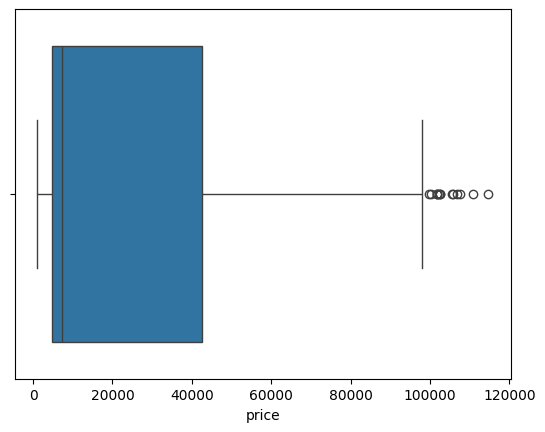

In [ ]:
sns.boxplot(x=train_copy['price'])

In [ ]:
(train_copy['price']>99000).sum()

np.int64(14)

In [ ]:
train_copy[train_copy['price']>99000]

,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price,route
3025,Vistara,UK-996,Mumbai,Evening,one,Night,Bangalore,Business,28.17,2.0,105764,Mumbai_Bangalore
4123,Vistara,UK-776,Kolkata,NaN,one,Afternoon,Delhi,Business,20.58,3.0,101780,Kolkata_Delhi
10056,Vistara,UK-910,Mumbai,Evening,NaN,Morning,Chennai,Business,16.33,7.0,100204,Mumbai_Chennai
10688,Vistara,UK-772,Kolkata,Morning,NaN,Night,Delhi,Business,11.17,17.0,101780,Kolkata_Delhi
12077,Vistara,UK-772,Kolkata,Morning,one,Evening,Hyderabad,Business,9.50,4.0,106753,Kolkata_Hyderabad
13000,Vistara,UK-706,Kolkata,NaN,two_or_more,Night,Mumbai,Business,10.00,4.0,110936,Kolkata_Mumbai
15928,NaN,UK-772,Kolkata,Morning,one,Night,Delhi,Business,13.33,5.0,102648,Kolkata_Delhi
20894,Vistara,UK-832,Chennai,NaN,one,Night,Mumbai,Business,15.08,5.0,114704,Chennai_Mumbai
20931,Vistara,UK-836,Chennai,Morning,one,Evening,Bangalore,Business,6.25,3.0,107597,Chennai_Bangalore
24173,Vistara,UK-910,Mumbai,Evening,one,Evening,Bangalore,Business,25.25,NaN,102404,Mumbai_Bangalore


From the EDA earlier we have seen that vistara flights has the highest median price and when we check for the outliers, it's all are business class tickets of vistara flights which can not be treated as outlier

<Axes: xlabel='duration'>

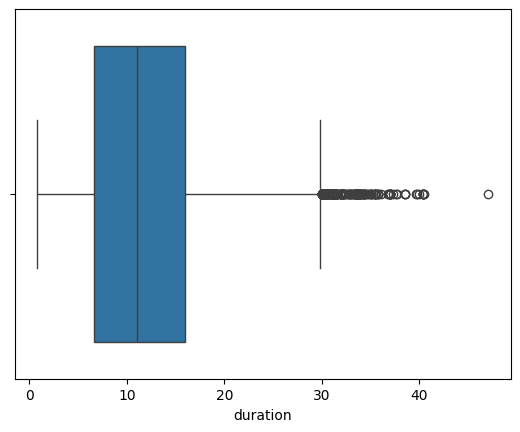

In [ ]:
sns.boxplot(x=train_copy['duration'])

In [ ]:
(train_copy['duration']>26).sum()

np.int64(1586)

In [ ]:
train_copy['duration'].skew()

np.float64(0.6094091828223132)

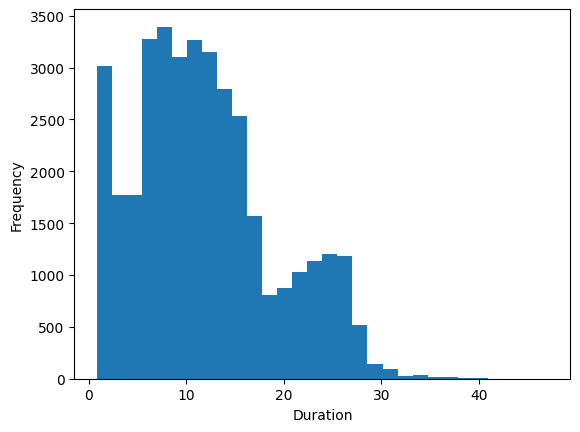

In [ ]:
plt.hist(train_copy['duration'], bins=30)
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

a moderately skwed feature

In [ ]:
train_copy['duration'].sort_values(ascending=False).head(20)

33948    47.08
24829    40.50
1953     40.42
35469    40.42
19663    40.42
13725    40.42
4099     40.42
33057    39.92
3848     39.75
24542    39.67
27365    38.58
4512     38.58
39800    38.58
17941    37.67
5820     37.58
11165    37.33
29847    37.00
35286    37.00
26023    37.00
29405    37.00
Name: duration, dtype: float64

In [ ]:
train_copy[['duration', 'stops','route']].sort_values('duration', ascending=False).head(20)

,duration,stops,route
33948,47.08,one,Chennai_Bangalore
24829,40.50,one,Kolkata_Mumbai
1953,40.42,NaN,Kolkata_Mumbai
35469,40.42,one,Kolkata_Mumbai
19663,40.42,one,Kolkata_Mumbai
13725,40.42,one,Kolkata_Mumbai
4099,40.42,one,Kolkata_Mumbai
33057,39.92,one,Chennai_Bangalore
3848,39.75,two_or_more,Mumbai_Chennai
24542,39.67,one,Hyderabad_Mumbai


In [ ]:
train_copy.groupby(pd.cut(train['duration'],
                  bins=[0,5,10,15,20,25,50]))['price'].mean()

/tmp/ipykernel_16/662537330.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_copy.groupby(pd.cut(train['duration'],


duration
(0, 5]       9437.919316
(5, 10]     17490.147716
(10, 15]    25036.351878
(15, 20]    27962.621856
(20, 25]    26864.092286
(25, 50]    22789.233139
Name: price, dtype: float64

This feature can not be treated as outlier either since short flights are cheaper and very long flights are cheaper again, which can be due to more layovers

<Axes: xlabel='days_left'>

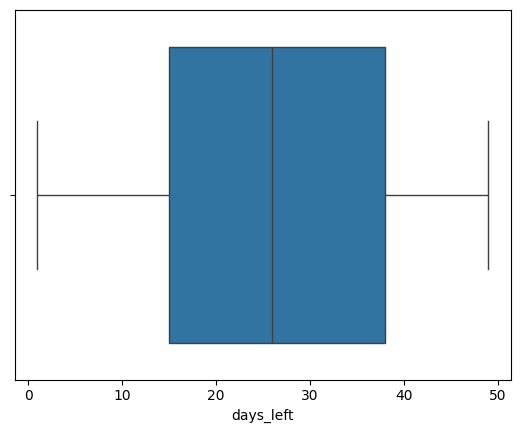

In [ ]:
sns.boxplot(x=train_copy['days_left'])

No visible outliers here
* All numerical values has been analyzed for outliers and no obvious outliers exist to drop them

In [ ]:
target = train_copy['price']

In [ ]:
train_copy = train_copy.drop(columns='price')

In [ ]:
X_test = test.copy().drop(columns = 'id')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_copy,
    target,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("test:", test.shape)

X_train: (31800, 11)
X_val: (7950, 11)
y_train: (31800,)
y_val: (7950,)
test: (10000, 12)


In [ ]:
print(X_train.columns)

Index(['airline', 'flight', 'source', 'departure', 'stops', 'arrival',
       'destination', 'class', 'duration', 'days_left', 'route'],
      dtype='object')


# handle missing values
I will be using the mode/most freequent stategy to handle missing data for categorical features and as for numerical features median will be suitable as there are not many missing samples and not enough relationship between them(for knn imputer) and median is more helpful for a skewed data than mean and also it can tolerate outliers better

In [ ]:
cat_cols = ['airline', 'departure','stops']
num_cols = ['duration','days_left']

In [ ]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

In [ ]:
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

In [ ]:
X_train.isnull().sum()

airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
route          0
dtype: int64

# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
X_train.head()

,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,route
23058,Vistara,UK-910,Mumbai,Evening,one,Night,Bangalore,Economy,-0.900796,0.222320,Mumbai_Bangalore
33447,AirAsia,I5-744,Delhi,Morning,one,Night,Chennai,Economy,0.015016,-0.013072,Delhi_Chennai
8365,Indigo,0.00E+00,Hyderabad,Morning,zero,Afternoon,Delhi,Economy,-1.388741,1.477743,Hyderabad_Delhi
29689,GO_FIRST,G8-7546,Mumbai,Evening,zero,Evening,Bangalore,Economy,-1.498639,-0.248464,Mumbai_Bangalore
19348,Vistara,UK-860,Hyderabad,Early_Morning,one,Evening,Mumbai,Business,-0.326399,0.614639,Hyderabad_Mumbai


# encoding

In [ ]:
class_mapping = {
    'Economy': 0,
    'Business': 1
}

X_train['class'] = X_train['class'].map(class_mapping)
X_val['class'] = X_val['class'].map(class_mapping)
X_test['class'] = X_test['class'].map(class_mapping)

In [ ]:
stops_mapping = {
    'zero': 0,
    'one': 1,
    'two_or_more': 2
}

X_train['stops'] = X_train['stops'].map(stops_mapping)
X_val['stops'] = X_val['stops'].map(stops_mapping)
X_test['stops'] = X_test['stops'].map(stops_mapping)

In [ ]:
X_train['flight'].nunique()

852

In [ ]:
# X_train_base = X_train.drop(columns='flight').copy()
# X_val_base = X_val.drop(columns='flight').copy()
# X_test_base = X_test.drop(columns='flight').copy()

In [ ]:
category_cols = [
    'airline',
    'source',
    'departure',
    'arrival',
    'destination',
    'route',
    'flight'
]

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [ ]:
train_encoded = encoder.fit_transform(X_train[category_cols])
val_encoded = encoder.transform(X_val[category_cols])
test_encoded = encoder.transform(X_test[category_cols])

In [ ]:
encoded_cols = encoder.get_feature_names_out(category_cols)

In [ ]:
train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

val_encoded = pd.DataFrame(
    val_encoded,
    columns=encoded_cols,
    index=X_val.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

In [ ]:
X_train_base = X_train.drop(columns=category_cols)
X_val_base = X_val.drop(columns=category_cols)
X_test_base = X_test.drop(columns=category_cols)

In [ ]:
X_train_base = pd.concat([X_train_base, train_encoded], axis=1)

X_val_base = pd.concat([X_val_base, val_encoded], axis=1)

X_test_base = pd.concat([X_test_base, test_encoded], axis=1)

In [ ]:
print(X_train_base.shape)
print(X_val_base.shape)
print(X_test_base.shape)

(31800, 916)
(7950, 916)
(10000, 916)


In [ ]:
X_train_base.head()

,stops,class,duration,days_left,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,...,flight_UK-975,flight_UK-977,flight_UK-981,flight_UK-985,flight_UK-986,flight_UK-988,flight_UK-993,flight_UK-994,flight_UK-995,flight_UK-996
23058,1,0,-0.900796,0.222320,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33447,1,0,0.015016,-0.013072,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8365,0,0,-1.388741,1.477743,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29689,0,0,-1.498639,-0.248464,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19348,1,1,-0.326399,0.614639,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_base, y_train)

LinearRegression()

In [ ]:
y_train_pred = lr.predict(X_train_base)

In [ ]:
y_val_pred = lr.predict(X_val_base)

In [ ]:
from sklearn.metrics import (
    r2_score
)

print("Train R² :", r2_score(y_train, y_train_pred))
print("Validation R² :", r2_score(y_val, y_val_pred))

Train R² : 0.9247493071886304
Validation R² : 0.9158655699423989


# ridge

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train_base, y_train)

Ridge()

In [ ]:
y_train_pred = ridge.predict(X_train_base)

In [ ]:
y_val_pred = ridge.predict(X_val_base)

In [ ]:
print("Train R² :", r2_score(y_train, y_train_pred))
print("Validation R² :", r2_score(y_val, y_val_pred))

Train R² : 0.9246586064409389
Validation R² : 0.9160333845081017


# Lasso

In [ ]:
# from sklearn.linear_model import Lasso
# lasso = Lasso(random_state=42)

# lasso.fit(X_train_base, y_train)

# train_pred = lasso.predict(X_train_base)
# val_pred = lasso.predict(X_val_base)

# print("Train R² :", r2_score(y_train, train_pred))
# print("Validation R² :", r2_score(y_val, val_pred))

In [ ]:
# from sklearn.tree import DecisionTreeRegressor
# dt = DecisionTreeRegressor(random_state=42)

# dt.fit(X_train_base, y_train)

# train_pred = dt.predict(X_train_base)
# val_pred = dt.predict(X_val_base)

# print("Train R² :", r2_score(y_train, train_pred))
# print("Validation R² :", r2_score(y_val, val_pred))

In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# rf = RandomForestRegressor(
#     random_state=42,
#     n_estimators=100,
#     n_jobs=-1
# )

# rf.fit(X_train_base, y_train)

# train_pred = rf.predict(X_train_base)
# val_pred = rf.predict(X_val_base)

# print("Train R² :", r2_score(y_train, train_pred))
# print("Validation R² :", r2_score(y_val, val_pred))

In [ ]:
# from sklearn.pipeline import Pipeline
# from sklearn.neural_network import MLPRegressor

# mlp = MLPRegressor(
#     hidden_layer_sizes=(128, 64),
#     activation='relu',
#     solver='adam',
#     learning_rate_init=0.001,
#     max_iter=500,
#     early_stopping=True,
#     # verbose=True,
#     random_state=42
# )

# mlp.fit(X_train_base, y_train)

# train_pred = mlp.predict(X_train_base)
# val_pred = mlp.predict(X_val_base)

# print("Train R² :", r2_score(y_train, train_pred))
# print("Validation R² :", r2_score(y_val, val_pred))

In [ ]:
# from sklearn.ensemble import GradientBoostingRegressor
# gbr = GradientBoostingRegressor(
#     random_state=42
# )

# gbr.fit(X_train_base, y_train)

# train_pred = gbr.predict(X_train_base)
# val_pred = gbr.predict(X_val_base)

# print("Train R² :", r2_score(y_train, train_pred))
# print("Validation R² :", r2_score(y_val, val_pred))

In [ ]:
# from xgboost import XGBRegressor
# xgb = XGBRegressor(
#     random_state=42,
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=6
# )

# xgb.fit(X_train_base, y_train)

# train_pred = xgb.predict(X_train_base)
# val_pred = xgb.predict(X_val_base)

# print("Train R² :", r2_score(y_train, train_pred))
# print("Validation R² :", r2_score(y_val, val_pred))

In [ ]:
# from sklearn.neighbors import KNeighborsRegressor

# knn = KNeighborsRegressor(n_neighbors=5)

# knn.fit(X_train_base, y_train)

# train_pred = knn.predict(X_train_base)
# val_pred = knn.predict(X_val_base)

# print("Train R² :", r2_score(y_train, train_pred))
# print("Validation R² :", r2_score(y_val, val_pred))

In [ ]:
# from sklearn.ensemble import AdaBoostRegressor

# ada = AdaBoostRegressor(
#     random_state=42,
#     n_estimators=100
# )

# ada.fit(X_train_base, y_train)

# train_pred = ada.predict(X_train_base)
# val_pred = ada.predict(X_val_base)

# print("Train R² :", r2_score(y_train, train_pred))
# print("Validation R² :", r2_score(y_val, val_pred))

In [ ]:
# from sklearn.ensemble import BaggingRegressor

# bag = BaggingRegressor(
#     random_state=42,
#     n_estimators=100
# )

# bag.fit(X_train_base, y_train)

# train_pred = bag.predict(X_train_base)
# val_pred = bag.predict(X_val_base)

# print("Train R² :", r2_score(y_train, train_pred))
# print("Validation R² :", r2_score(y_val, val_pred))

In [ ]:
# from sklearn.ensemble import VotingRegressor

# voting = VotingRegressor([
#     ('rf', RandomForestRegressor(random_state=42)),
#     ('xgb', XGBRegressor(random_state=42)),
#     ('gbr', GradientBoostingRegressor(random_state=42))
# ])

# voting.fit(X_train_base, y_train)

# train_pred = voting.predict(X_train_base)
# val_pred = voting.predict(X_val_base)

# print("Train R² :", r2_score(y_train, train_pred))
# print("Validation R² :", r2_score(y_val, val_pred))

# tuning

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.ensemble import RandomForestRegressor

# rf = RandomForestRegressor(random_state=42)

# param_dist = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2', None]
# }

# rf_random = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=40,
#     cv=3,
#     scoring='r2',
#     random_state=42,
#     n_jobs=-1,
#     verbose=2
# )

# rf_random.fit(X_train_base, y_train)
# print('done')

In [ ]:
# import joblib

# joblib.dump(rf_random, "/kaggle/working/rf_tuned.pkl")

In [ ]:
# rf_tuned = joblib.load("/kaggle/working/rf_tuned.pkl")

In [ ]:
# # 4. Evaluate
# from sklearn.metrics import r2_score

# val_pred = rf_random.predict(X_val_base)
# print("Validation R²:", r2_score(y_val, val_pred))

In [ ]:
# from xgboost import XGBRegressor

# xgb = XGBRegressor(random_state=42)

# param_dist = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

# xgb_random = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_dist,
#     n_iter=10,
#     cv=5,
#     scoring='r2',
#     random_state=42,
#     n_jobs=-1,
#     verbose=2
# )

# xgb_random.fit(X_train_base, y_train)

In [ ]:
# best_xgb = xgb_random.best_estimator_

# val_pred = best_xgb.predict(X_val_base)

# print("Validation R² :", r2_score(y_val, val_pred))

In [ ]:
# from sklearn.ensemble import VotingRegressor

# voting = VotingRegressor([
#     ('rf', rf),
#     ('xgb', xgb),
#     ('gbr', gbr)
# ])

# voting.fit(X_train_base, y_train)

# val_pred = voting.predict(X_val_base)

# print("Validation R² :", r2_score(y_val, val_pred))

# import joblib

# joblib.dump(voting, "/kaggle/working/voting_regressor.pkl")

In [ ]:
# voting = joblib.load("/kaggle/working/voting_regressor.pkl")

In [ ]:
# voting_pred = voting_tuned.predict(X_test_base)
# voting_val_pred = voting_tuned.predict(X_val_base)

In [ ]:
# from sklearn.metrics import r2_score

# val_pred = voting.predict(X_val_base)

# print("Validation R²:", r2_score(y_val, val_pred))

In [ ]:
# from sklearn.ensemble import BaggingRegressor
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.model_selection import RandomizedSearchCV

# # Base estimator
# base_tree = DecisionTreeRegressor(random_state=42)

# # Bagging model
# bagging = BaggingRegressor(
#     estimator=base_tree,
#     random_state=42,
#     n_jobs=-1
# )

# # Hyperparameter space
# param_dist = {
#     'n_estimators': [10, 25, 50, 100, 200],
#     'max_samples': [0.5, 0.7, 0.9, 1.0],
#     'max_features': [0.5, 0.7, 0.9, 1.0],
#     'bootstrap': [True, False],
#     'bootstrap_features': [True, False]
# }

# # Random Search
# bagging_random = RandomizedSearchCV(
#     estimator=bagging,
#     param_distributions=param_dist,
#     n_iter=10,
#     cv=4,
#     scoring='r2',
#     random_state=42,
#     n_jobs=-1,
#     verbose=2
# )

# # Train
# bagging_random.fit(X_train_base, y_train)

# # print("Best Parameters:", bagging_random.best_params_)
# print("Best CV Score:", bagging_random.best_score_)

# best_bagging = bagging_random.best_estimator_

# # Predict on validation set
# y_pred = best_bagging.predict(X_val_base)

# # Calculate R²
# r2 = r2_score(y_val, y_pred)

# print("Validation R²:", r2)

In [ ]:
# joblib.dump(bagging_random, "/kaggle/working/bagging.pkl")

In [ ]:
# bagging_tuned = joblib.load("/kaggle/working/bagging.pkl")

In [ ]:
# bagging_pred = bagging_tuned.predict(X_test_base)

In [ ]:
# bagging_val_pred = bagging_tuned.predict(X_val_base)

In [ ]:
# best_bagging = bagging_random.best_estimator_

# # Predict on validation set
# y_pred = best_bagging.predict(X_val_base)

# # Calculate R²
# r2 = r2_score(y_val, y_pred)

# print("Validation R²:", r2)

# submission

In [ ]:
X_train_final = pd.concat([X_train_base, X_val_base], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

In [ ]:
X_train_final.shape

(39750, 916)

In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# rf = RandomForestRegressor(
#     random_state=42,
#     n_estimators=100,
#     n_jobs=-1
# )

# rf.fit(X_train_final, y_train_final)

# train_pred = rf.predict(X_train_final)


# print("Train R² :", r2_score(y_train_final, train_pred))


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    random_state=42,
    n_estimators=200,
    n_jobs=-1
)

rf.fit(X_train_final, y_train_final)

rf_pred = rf.predict(X_train_final)


print("Train R² :", r2_score(y_train_final, rf_pred))


Train R² : 0.9967380929453324


In [ ]:
# from sklearn.ensemble import BaggingRegressor

# bag = BaggingRegressor(
#     random_state=42,
#     n_estimators=100
# )

# bag.fit(X_train_final, y_train_final)

# bag_pred = bag.predict(X_train_final)

# print("Train R² :", r2_score(y_train_final, train_pred))

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist'
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb, X_train_final, y_train_final, cv=kf, scoring='r2', n_jobs=-1)

print("CV R²:", scores.mean())

CV R²: 0.978462815284729


In [ ]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import cross_val_score, KFold
# import numpy as np

# xgb = XGBRegressor(
#     n_estimators=3000,
#     learning_rate=0.02,
#     max_depth=6,
#     min_child_weight=3,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     gamma=0.1,
#     reg_alpha=0.1,
#     reg_lambda=1.0,
#     objective='reg:squarederror',
#     random_state=42,
#     tree_method='hist'
# )

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(xgb, X_train_final, y_train_final, cv=kf, scoring='r2', n_jobs=-1)

# print("CV R²:", scores.mean())

In [ ]:
xgb.fit(X_train_final, y_train_final)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_train_final)
print("Train R² :", r2_score(y_train_final, xgb_pred))

Train R² : 0.9879409670829773


In [ ]:
RF_pred = rf.predict(X_test_base)

In [ ]:
XGB_pred = xgb.predict(X_test_base)

In [ ]:
final_pred = 0.9*XGB_pred + 0.1*RF_pred

In [ ]:
sample_submission = pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/sample_submission.csv")

In [ ]:
sample_submission["price"] = final_pred

In [ ]:
sample_submission.head()

,id,price
0,0,4424.796270
1,1,10112.632953
2,2,5250.625086
3,3,58095.917287
4,4,47747.813406


In [ ]:
sample_submission.to_csv("submission.csv", index=False)

In [ ]:
print(sample_submission.shape)
print(test.shape)

(10000, 2)
(10000, 12)


In [ ]:
# # Load models
# rf = joblib.load(...)
# xgb = joblib.load(...)
# voting = joblib.load(...)

# # Predict
# pred = voting.predict(X_test_base)

# # Create submission
# sample_submission["price"] = pred

# sample_submission.to_csv("submission.csv", index=False)